In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# this is the code to load the MNIST dataset
# it will need some time to run
from sklearn.datasets import fetch_openml
X, y = fetch_openml("mnist_784", version=1, return_X_y=True, as_frame=False)


In [3]:
print(X.shape, y.shape)

(70000, 784) (70000,)


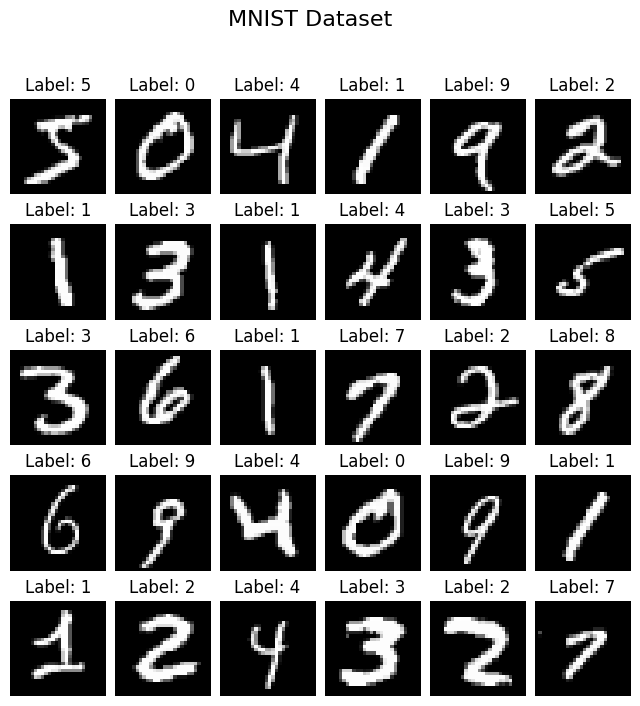

In [4]:

fig = plt.figure(figsize=(8, 8))
fig.suptitle("MNIST Dataset", fontsize=16)
fig.subplots_adjust(wspace=0.1, hspace=0.1)
for i in range(30):
    images = X[i].reshape(28, 28)
    ax = fig.add_subplot(5, 6, i + 1)
    ax.imshow(images, cmap="gray")
    ax.set_title(f"Label: {y[i]}")
    ax.axis("off")
plt.show()

In [5]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)
print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)

(46900, 784) (46900,)
(23100, 784) (23100,)


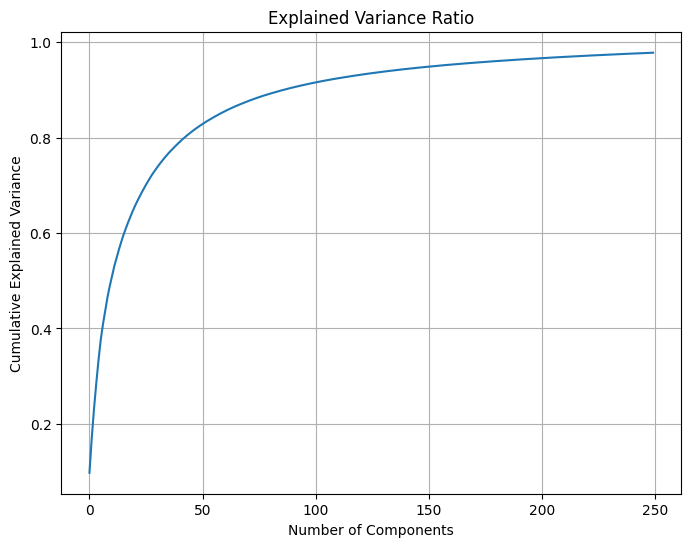

In [6]:
from sklearn.decomposition import PCA
pca = PCA(n_components=250)
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)

ax = plt.figure(figsize=(8, 6)).gca()
ax.plot(np.cumsum(pca.explained_variance_ratio_))
ax.set_xlabel("Number of Components")
ax.set_ylabel("Cumulative Explained Variance")
ax.set_title("Explained Variance Ratio")
plt.grid()
plt.show()

In [7]:
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix
import time 

#######################
time_now = time.time()
#######################

"""
this works but it takes a long time to run, so I will not run it in the notebook
svm_clf = SVC(kernel="rbf", random_state=42)
svm_clf.fit(X_train_pca, y_train)
y_pred = svm_clf.predict(X_test_pca)
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
"""
# linear svm is much faster to train, but it may not perform as well as the rbf kernel
from sklearn.svm import LinearSVC

# I will try linear svm with 100 components, which explains about 90% of the variance
pca = PCA(n_components=100)
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)

#######################
time_PCA = time.time()
#######################

#linear svm
linear_svm_clf = LinearSVC(random_state=42)
linear_svm_clf.fit(X_train_pca, y_train)
y_pred_linear = linear_svm_clf.predict(X_test_pca)

#######################
time_linear_svm = time.time()
#######################

print(classification_report(y_test, y_pred_linear))
print(f"Time taken for PCA: {time_PCA - time_now}")
print(f"Time taken for Linear SVM: {time_linear_svm - time_PCA}")

              precision    recall  f1-score   support

           0       0.95      0.97      0.96      2267
           1       0.93      0.98      0.95      2603
           2       0.90      0.88      0.89      2350
           3       0.89      0.88      0.89      2383
           4       0.90      0.92      0.91      2144
           5       0.88      0.83      0.85      2107
           6       0.93      0.96      0.94      2294
           7       0.92      0.93      0.92      2455
           8       0.88      0.84      0.86      2196
           9       0.88      0.86      0.87      2301

    accuracy                           0.91     23100
   macro avg       0.90      0.90      0.90     23100
weighted avg       0.91      0.91      0.91     23100

Time taken for PCA: 0.9256083965301514
Time taken for Linear SVM: 248.37588214874268


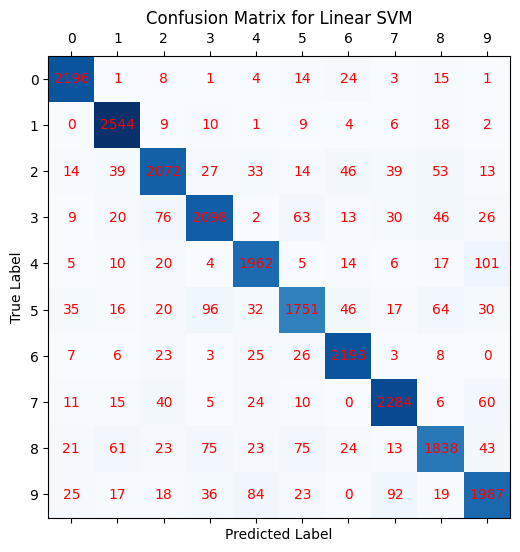

In [8]:
# confusion matrix for linear svm in matplotlib
ax = plt.figure(figsize=(8, 6)).gca()
ax.matshow(confusion_matrix(y_test, y_pred_linear), cmap=plt.cm.Blues)
for i in range(10):
    for j in range(10):
        ax.text(j, i, str(confusion_matrix(y_test, y_pred_linear)[i, j]),
                ha="center", va="center", color="red")

ax.set_xlabel("Predicted Label")
ax.set_ylabel("True Label")
ax.set_title("Confusion Matrix for Linear SVM")
size = len(np.unique(y_test))
ax.set_xticks(np.arange(size))
ax.set_yticks(np.arange(size))
plt.show()


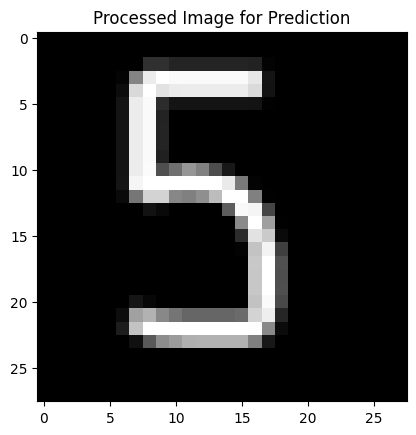

In [9]:
import tkinter as tk
from PIL import Image, ImageDraw, ImageOps

class DigitRecognizer(tk.Tk):
    def __init__(self):
        super().__init__()
        self.title("MNIST Digit Recognizer")
        self.canvas_width = 280
        self.canvas_height = 280
        self.canvas = tk.Canvas(self, width=self.canvas_width,
                                height=self.canvas_height, bg="white")
        self.canvas.pack()
        # keep a PIL image to record the strokes
        self.image = Image.new("L", (self.canvas_width, self.canvas_height), color=255)
        self.draw = ImageDraw.Draw(self.image)
        self.last_x = None
        self.last_y = None
        self.canvas.bind("<B1-Motion>", self.paint)
        self.canvas.bind("<ButtonRelease-1>", self.reset)
        self.predict_button = tk.Button(self, text="Predict", command=self.predict)
        self.predict_button.pack(side="left")
        self.clear_button = tk.Button(self, text="Clear", command=self.clear)
        self.clear_button.pack(side="left")
        self.result_label = tk.Label(self, text="Draw a digit and click predict")
        self.result_label.pack(side="left")

    def paint(self, event):
        x, y = event.x, event.y
        if self.last_x is not None and self.last_y is not None:
            self.canvas.create_line(self.last_x, self.last_y, x, y,
                                    width=21, fill="black",
                                    capstyle=tk.ROUND, smooth=True)
            self.draw.line([self.last_x, self.last_y, x, y],
                           fill=0, width=21)
        self.last_x, self.last_y = x, y

    def reset(self, event):
        self.last_x, self.last_y = None, None

    def clear(self):
        self.canvas.delete("all")
        self.draw.rectangle([0, 0, self.canvas_width, self.canvas_height],
                            fill=255)
        self.result_label.config(text="Draw a digit and click predict")

    def predict(self):
        # resize to 28x28, invert colours (MNIST is white-on‑black)
        img = self.image.resize((28, 28))
        img = ImageOps.invert(img)
        plt.imshow(img, cmap="gray")
        plt.title("Processed Image for Prediction")
        arr = np.array(img, dtype=np.float32).reshape(1, -1)
        arr_pca = pca.transform(arr)           # existing PCA instance
        pred = linear_svm_clf.predict(arr_pca) # existing trained classifier
        self.result_label.config(text=f"Prediction: {pred[0]}")

# run the GUI
if __name__ == "__main__":
    app = DigitRecognizer()
    app.mainloop()